In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import MSTL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from time import time
import seaborn as sns
sns.set_style("darkgrid")
plt.rc("figure", figsize=(16, 12))

https://www.statsmodels.org/dev/examples/notebooks/generated/mstl_decomposition.html

In [2]:
# Load datasets from project root (notebook in src/)
from pathlib import Path
root = Path.cwd().resolve().parents[0]  # project root when running from src/

train_path = root / 'data' / 'NSW' / 'train.csv'
validation_path = root / 'data' / 'NSW' / 'validation.csv'
test_path = root / 'data' / 'NSW' / 'test.csv'


train = pd.read_csv(train_path, parse_dates=['DATETIME'], index_col='DATETIME')
validation = pd.read_csv(validation_path, parse_dates=['DATETIME'], index_col='DATETIME')
test = pd.read_csv(test_path, parse_dates=['DATETIME'], index_col='DATETIME')

# Quick check
print("Train shape:", train.shape)
print("Validation shape:", validation.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (112651, 7)
Validation shape: (37550, 7)
Test shape: (37552, 55)


,TOTALDEMAND,demand_1_day_ago,demand_1_week_ago,demand_1_year_ago,TEMPERATURE,RMSE_48,TSE_48
DATETIME,,,,,,,
2010-07-02 12:00:00,11409.84,10035.63,9766.12,8038.00,11.0,637.616980,1.951466e+07
2010-07-02 12:30:00,11276.77,9686.17,9521.15,7809.31,11.5,706.576978,2.396405e+07
2010-07-02 13:00:00,11208.75,9513.42,9318.45,7483.69,11.6,784.498292,2.954100e+07
2010-07-02 13:30:00,11184.47,9255.59,9108.57,7117.23,11.8,862.789475,3.573147e+07
2010-07-02 14:00:00,11141.20,9019.79,8863.47,6812.03,12.0,927.314578,4.127579e+07


In [3]:
train.index.freq = '30min'
validation.index.freq = '30min'
test.index.freq = '30min'

In [ ]:
#train.info()

In [ ]:
#train.describe()

In [ ]:
#train[train['TEMPERATURE'] > 30]['TEMPERATURE'].describe()

<Axes: title={'center': 'Total Demand (last 17532 hours)'}, xlabel='DATETIME', ylabel='MW'>

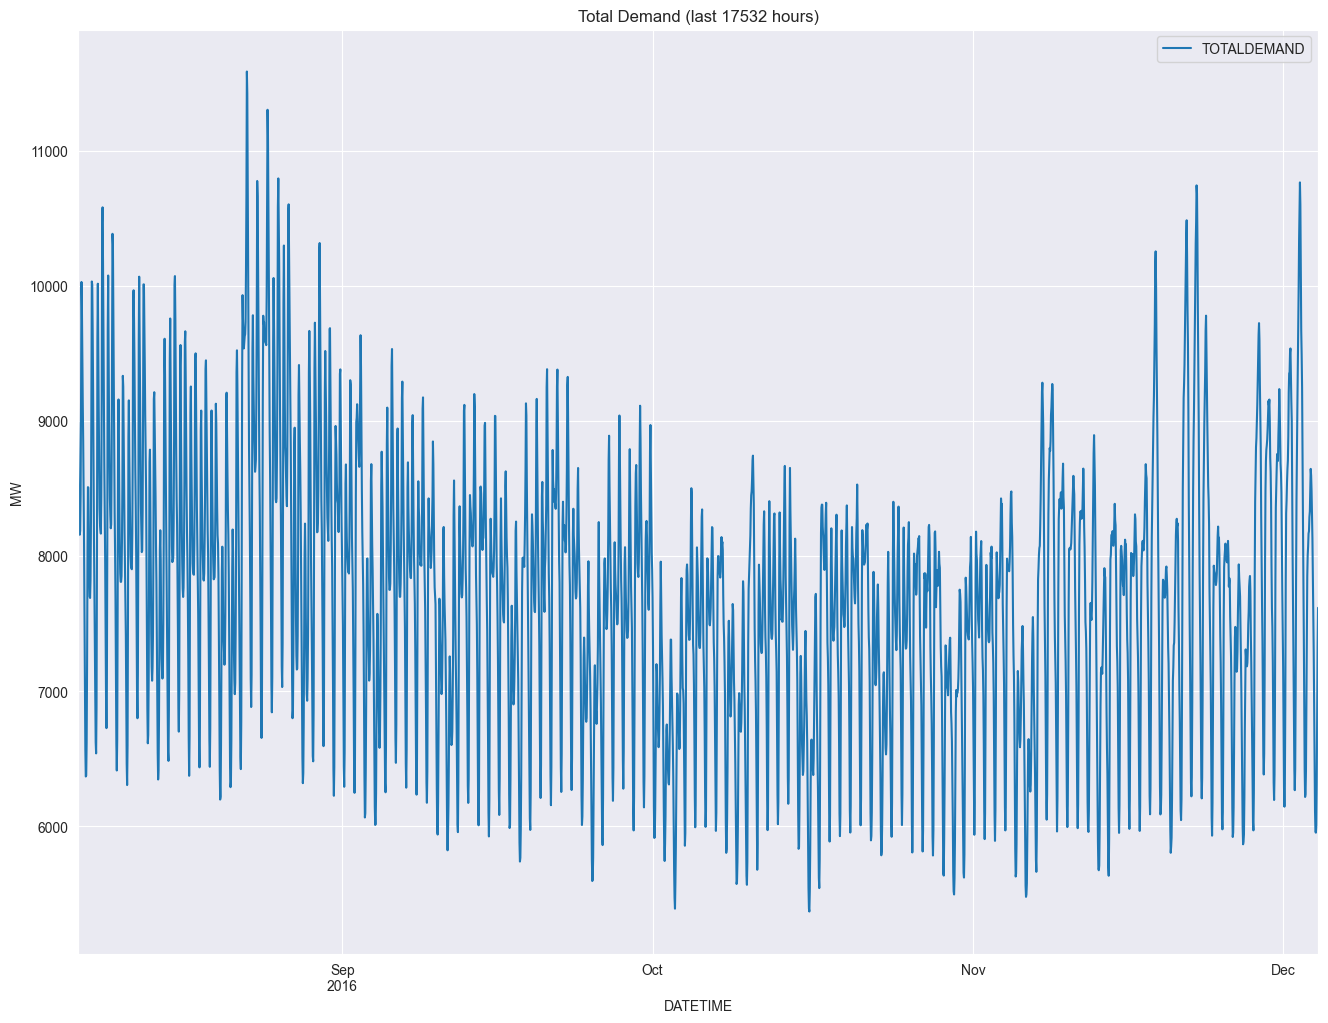

In [ ]:
# lookback_window = 17532
# subset_train = train[train.index.max() - pd.Timedelta(hours=lookback_window/2):]

# temp_subset_train = subset_train.copy()
# # group by hour
# temp_subset_train = temp_subset_train.resample('1h').mean()
# temp_subset_train.iloc[-720*4:].plot(y='TOTALDEMAND', title='Total Demand (last 17532 hours)', ylabel='MW')

In [ ]:
# stl = MSTL(
#     subset_train['TOTALDEMAND'], 
#     windows=(11, 15, 19*4-1),
#     periods=(48, 336, 48*30),
#     iterate=3,
#     stl_kwargs={"seasonal_deg": 0, "inner_iter": 2, "outer_iter": 0})
# res = stl.fit()
# plt.figure(figsize=(16,12))
# fig = res.plot()
# plt.show()

In [ ]:
# res.trend

In [ ]:
# fig, ax = plt.subplots(nrows=5, figsize=[16, 16])
# res.seasonal["seasonal_48"].iloc[: 48 * 7].plot(ax=ax[0])
# ax[0].set_ylabel("seasonal_48")
# ax[0].set_title("Daily seasonality")

# res.seasonal["seasonal_336"].iloc[: 336 * 26].plot(ax=ax[1])
# ax[1].set_ylabel("seasonal_336")
# ax[1].set_title("Weekly seasonality")

# res.seasonal["seasonal_1440"].iloc[: 1440 * 3].plot(ax=ax[2])
# ax[2].set_ylabel("seasonal_1440")
# ax[2].set_title("Monthly seasonality")

# res.trend.iloc[: 48 * 365].plot(ax=ax[3])
# ax[3].set_ylabel("trend")
# ax[3].set_title("Trend")

# res.resid.iloc[: 48 * 365].plot(ax=ax[4])
# ax[4].set_ylabel("residuals")
# ax[4].set_title("Residuals")

# plt.tight_layout()

In [ ]:
##acf_plot = plot_acf(subset_train['TOTALDEMAND'], lags=min(48, len(subset_train)/2-1))

In [ ]:
#pacf_plot = plot_pacf(subset_train['TOTALDEMAND'], lags=min(48, len(subset_train)/2-1))

https://otexts.com/fpp3/

The data is not stationary because of obvious seasonality trends. The ACF also supports this fact that it slowly decreases and increases again.

In [ ]:
#plt.rc("figure", figsize=(10, 6))

In [ ]:
# diff_48 = subset_train['TOTALDEMAND'].diff(48).dropna()
# stl_48 = MSTL(
#     diff_48, 
#     windows=(11, 15, 19*4-1),
#     periods=(48, 336, 48*30),
#     iterate=3,
#     stl_kwargs={"seasonal_deg": 0, "inner_iter": 2, "outer_iter": 0})
# res_48 = stl_48.fit()

In [ ]:
# fig = res_48.plot()
# plt.show()
# diff_48.iloc[:lookback_window//2].plot(title='Seasonal Differencing (lag=48)')
# pacf_plot_diff_48 = plot_acf(diff_48, lags=min(48, len(diff_48)/2-1))

# fig, ax = plt.subplots(nrows=5)
# res_48.seasonal["seasonal_48"].iloc[: 48 * 7].plot(ax=ax[0])
# ax[0].set_ylabel("seasonal_48")
# ax[0].set_title("Daily seasonality")

# res_48.seasonal["seasonal_336"].iloc[: 336 * 26].plot(ax=ax[1])
# ax[1].set_ylabel("seasonal_336")
# ax[1].set_title("Weekly seasonality")

# res_48.seasonal["seasonal_1440"].iloc[: 1440 * 3].plot(ax=ax[2])
# ax[2].set_ylabel("seasonal_1440")
# ax[2].set_title("Monthly seasonality")

# res_48.trend.iloc[: 48 * 365].plot(ax=ax[3])
# ax[3].set_ylabel("trend")
# ax[3].set_title("Trend")

# res_48.resid.iloc[: 48 * 365].plot(ax=ax[4])
# ax[4].set_ylabel("residuals")
# ax[4].set_title("Residuals")

# plt.tight_layout()

In [ ]:
# # Create differenced series
# diff_1 = diff_48.diff().dropna()
# diff_1.iloc[:720].plot(title='First Order Differencing')
# stl_1 = MSTL(
#     diff_1, 
#     windows=(11, 15, 19*4-1),
#     periods=(48, 336, 48*30),
#     iterate=3,
#     stl_kwargs={"seasonal_deg": 0, "inner_iter": 2, "outer_iter": 0})
# res_1 = stl_1.fit()

In [ ]:
# fig = res_1.plot()
# plt.show()
# diff_1.iloc[:lookback_window//2].plot(title='Seasonal Differencing (lag=48)')
# acf_plot_diff_1 = plot_acf(diff_1, lags=min(48, len(diff_1)/2-1))
# pacf_plot_diff_1 = plot_pacf(diff_1, lags=min(48, len(diff_1)/2-1))
# fig, ax = plt.subplots(nrows=5, figsize=[16, 16])
# res_1.seasonal["seasonal_48"].iloc[: 48 * 7].plot(ax=ax[0])
# ax[0].set_ylabel("seasonal_48")
# ax[0].set_title("Daily seasonality")

# res_1.seasonal["seasonal_336"].iloc[: 336 * 26].plot(ax=ax[1])
# ax[1].set_ylabel("seasonal_336")
# ax[1].set_title("Weekly seasonality")

# res_1.seasonal["seasonal_1440"].iloc[: 1440 * 3].plot(ax=ax[2])
# ax[2].set_ylabel("seasonal_1440")
# ax[2].set_title("Monthly seasonality")

# res_1.trend.iloc[: 48 * 365].plot(ax=ax[3])
# ax[3].set_ylabel("trend")
# ax[3].set_title("Trend")

# res_1.resid.iloc[: 48 * 365].plot(ax=ax[4])
# ax[4].set_ylabel("residuals")
# ax[4].set_title("Residuals")

# plt.tight_layout()

In [ ]:
# plt.rc("figure", figsize=(10, 6))

In [5]:
lookback_window = 1440
horizon = 720
subset_train = train[train.index.max() - pd.Timedelta(hours=lookback_window//2):train.index.max()]
validation_target = validation.iloc[:horizon+1]

In [6]:
subset_train['LOG_TOTALDEMAND'] = np.log(subset_train['TOTALDEMAND'])
validation_target['LOG_TOTALDEMAND'] = np.log(validation_target['TOTALDEMAND'])
subset_train['TEMP_SQUARED'] = subset_train['TEMPERATURE'] ** 2
subset_train['IS_WEEKEND'] = (subset_train.index.weekday >= 5).astype(int)  # 1 for Saturday/Sunday, else 0
subset_train['IS_HEAT_WAVE'] = ((subset_train['TEMPERATURE'] > 33)).astype(int)
validation_target['TEMP_SQUARED'] = validation_target['TEMPERATURE'] ** 2
validation_target['IS_WEEKEND'] = (validation_target.index.weekday >= 5).astype(int)  # 1 for Saturday/Sunday, else 0
validation_target['IS_HEAT_WAVE'] = ((validation_target['TEMPERATURE'] > 33)).astype(int)

exog = ['demand_1_week_ago', 'demand_1_year_ago', 'TEMPERATURE','TEMP_SQUARED', 'IS_WEEKEND', 'IS_HEAT_WAVE']

In [7]:
p = 4
d = 0
q = 0
p_s = 1
d_s = 1
q_s = 1
period = 48

model_sarima = SARIMAX(
    subset_train['LOG_TOTALDEMAND'], 
    exog=subset_train[exog],
    order=(p,d,q), 
    seasonal_order=(p_s,d_s,q_s,period)
    )
start = time()
model_fit_sarima = model_sarima.fit()
end = time()
print(f"SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) Model fitting took {end - start:.2f} seconds")
print(model_fit_sarima.summary())

SARIMA(4,0,0)(1,1,1,48) Model fitting took 59.15 seconds
                                      SARIMAX Results                                       
Dep. Variable:                      LOG_TOTALDEMAND   No. Observations:                 1441
Model:             SARIMAX(4, 0, 0)x(1, 1, [1], 48)   Log Likelihood                3941.526
Date:                              Sun, 05 Apr 2026   AIC                          -7857.051
Time:                                      19:29:45   BIC                          -7788.941
Sample:                                  11-04-2016   HQIC                         -7831.584
                                       - 12-04-2016                                         
Covariance Type:                                opg                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
demand_1_week_ago  4.238e-0

In [ ]:
# model_fit_sarima.resid.plot(title=f'Residuals of SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) on Training Set')
# resid_acf_plot = plot_acf(model_fit_sarima.resid, lags=(len(model_fit_sarima.resid)-1)//4)
# resid_pacf_plot = plot_pacf(model_fit_sarima.resid, lags=(len(model_fit_sarima.resid)-1)//4)

In [ ]:
# from datetime import datetime, timedelta

# print(validation_target.index.min(), validation_target.index.max())
# predictions = model_fit_sarima.forecast(
#     steps=len(validation_target), 
#     exog=validation_target[exog]
# )
# residuals = validation_target['LOG_TOTALDEMAND'] - predictions

# plt.figure(figsize=(12,4))
# plt.plot(residuals)
# plt.title(f'Residuals of SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) on Validation Set')
# plt.ylabel('Residual')
# # for xticks, show as format 'YYYY-MM-DD HH'
# plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
# plt.xticks(np.arange(validation_target.index[0], validation_target.index[-1], step=timedelta(hours=6)), rotation=45, fontsize=8)
# plt.axhline(0, color='red', linestyle='--', alpha=0.2)
# plt.show()

# plt.figure(figsize=(12,4))
# plt.plot(validation_target['TOTALDEMAND'], label='Actual')
# plt.plot(np.exp(predictions), label='Predicted', linestyle='--')
# plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
# plt.xticks(np.arange(validation_target.index[0], validation_target.index[-1], step=timedelta(hours=6)), rotation=45, fontsize=8)
# plt.title(f'Actual vs Predicted of SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) on Validation Set')
# plt.legend()
# plt.show()

In [8]:
validation_target = validation
validation_target['LOG_TOTALDEMAND'] = np.log(validation_target['TOTALDEMAND'])
validation_target['TEMP_SQUARED'] = validation_target['TEMPERATURE'] ** 2
validation_target['IS_WEEKEND'] = (validation_target.index.weekday >= 5).astype(int)  # 1 for Saturday/Sunday, else 0
validation_target['IS_HEAT_WAVE'] = ((validation_target['TEMPERATURE'] > 33)).astype(int)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import timedelta

forecast_horizon = 720  
step_size = 48         

origins = range(0, len(validation_target) - forecast_horizon, step_size)
print(f"Rolling forecast origins: {len(list(origins))}")

all_actuals = []
all_predictions = []
all_timestamps = []

# Start our 'rolling' state with the base model trained on subset_train
rolling_state = model_fit_sarima

for i in origins:
    # 1. First, make the forecast from the current state
    future_exog = validation_target[exog].iloc[i : i + forecast_horizon]
    forecast = rolling_state.forecast(steps=forecast_horizon, exog=future_exog)
    
    # Store predictions and actuals
    all_predictions.extend(np.exp(forecast.values))
    all_actuals.extend(validation_target['TOTALDEMAND'].iloc[i : i + forecast_horizon].values)
    all_timestamps.extend(validation_target.index[i : i + forecast_horizon].tolist())
    
    if (i // step_size) % 10 == 0 and i > 0:
        mae_so_far  = mean_absolute_error(all_actuals, all_predictions)
        rmse_so_far = np.sqrt(mean_squared_error(all_actuals, all_predictions))
        mape_so_far = np.mean(np.abs((np.array(all_actuals) - np.array(all_predictions)) / np.array(all_actuals))) * 100
        print(f"Origin {i//step_size}: MAE so far: {mae_so_far:.2f} MW | RMSE so far: {rmse_so_far:.2f} MW | MAPE so far: {mape_so_far:.2f}%")

    # 2. Then, advance the Origin forward by 'step_size'
    # We do this by APPENDING the model state with the actuals that occurred during that step
    new_endog = validation_target['LOG_TOTALDEMAND'].iloc[i : i + step_size]
    new_exog = validation_target[exog].iloc[i : i + step_size]
    
    # .extend() updates the internal Kalman filter state efficiently
    rolling_state = rolling_state.extend(new_endog, exog=new_exog)

all_actuals = np.array(all_actuals)
all_predictions = np.array(all_predictions)

mae  = mean_absolute_error(all_actuals, all_predictions)
rmse = np.sqrt(mean_squared_error(all_actuals, all_predictions))
mape = np.mean(np.abs((all_actuals - all_predictions) / all_actuals)) * 100
print(f"Rolling Forecast (h={forecast_horizon} steps) — MAE: {mae:.2f} MW | RMSE: {rmse:.2f} MW | MAPE: {mape:.2f}%")

# Plot
plt.figure(figsize=(14, 4))
plt.plot(all_timestamps, all_actuals, label='Actual')
plt.plot(all_timestamps, all_predictions, label='Predicted', linestyle='--', alpha=0.8)
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
plt.xticks(rotation=45, fontsize=8)
plt.title(f'Rolling Forecast from Origin — SARIMAX({p},{d},{q})({p_s},{d_s},{q_s},{period}), h={forecast_horizon}')
plt.legend()
plt.tight_layout()
plt.show()

Rolling forecast origins: 768


In [ ]:
all_predictions.shape

In [ ]:
# import pmdarima as pm

# # Auto-fit the SARIMA model
# # Note: Since your data is 30-min intervals, your seasonal period (m) is 48 for daily seasonality.
# auto_model = pm.auto_arima(
#     y=subset_train['TOTALDEMAND'],
#     X=subset_train[exog],
#     start_p=4, start_q=0,
#     max_p=5, max_q=3,
#     m=48,              # Seasonal period (48 for daily seasonality with 30-min data)
#     start_P=1, start_Q=0,
#     max_P=7, max_Q=2,
#     d=None,            # Let the model determine 'd'
#     D=None,            # Let the model determine 'D'
#     seasonal=True,     # Enable SARIMA
#     trace=True,        # Print the search progress
#     error_action='ignore',  
#     suppress_warnings=True, 
#     stepwise=True,      # False for full grid search (rather than stepwise algorithm)
#     num_workers=-1,
#     max_order = 7
# )

In [ ]:
# from datetime import datetime, timedelta

# print(validation_target.index.min(), validation_target.index.max())
# predictions = auto_model.predict(
#     n_periods=len(validation_target),
#     X=validation_target[exog]
# )
# residuals = validation_target['TOTALDEMAND'] - predictions

# plt.figure(figsize=(12,4))
# plt.plot(residuals)
# plt.title(f'Residuals of SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) on Validation Set')
# plt.ylabel('Residual')
# # for xticks, show as format 'YYYY-MM-DD HH'
# plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
# plt.xticks(np.arange(validation_target.index[0], validation_target.index[-1], step=timedelta(hours=6)), rotation=45, fontsize=8)
# plt.axhline(0, color='red', linestyle='--', alpha=0.2)
# plt.show()

# plt.figure(figsize=(12,4))
# plt.plot(validation_target['TOTALDEMAND'], label='Actual')
# plt.plot(predictions, label='Predicted', linestyle='--')
# plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d %H'))
# plt.xticks(np.arange(validation_target.index[0], validation_target.index[-1], step=timedelta(hours=6)), rotation=45, fontsize=8)
# plt.title(f'Actual vs Predicted of SARIMA({p},{d},{q})({p_s},{d_s},{q_s},{period}) on Validation Set')
# plt.legend()
# plt.show()